# Stroke Prediction DS

This project explores the **Stroke Prediction Dataset** to identify which demographic, lifestyle, and clinical characteristics are statistically associated with having a stroke. After cleaning the data and introducing additional numeric features, we compute descriptive statistics, visualise distributions and relationships, and test hypotheses using non-parametric methods chosen to suit the data's non-normal, highly imbalanced nature.

## Dataset Description

**Subject area:** public-health / clinical data on stroke risk. Each of 5,110 rows is one patient; the binary `stroke` column is the result.

| Column | Type | Description |
|---|---|---|
| `id` | indexing (identifier) | Unique patient ID (dropped) |
| `gender` | categorical | Male, Female, Other |
| `age` | numeric | Age in years |
| `hypertension` | binary | 1 = has hypertension |
| `heart_disease` | binary | 1 = has heart disease |
| `ever_married` | categorical | Yes / No |
| `work_type` | categorical | children, Govt_job, Never_worked, Private, Self-employed |
| `Residence_type` | categorical | Urban / Rural |
| `avg_glucose_level` | numeric | Average blood glucose |
| `bmi` | numeric | Body mass index |
| `smoking_status` | categorical | formerly smoked, never smoked, smokes, Unknown |
| `stroke` | binary (target) | 1 = had a stroke |

**Source:** published on Kaggle (2021) by *fedesoriano*; listed only as a confidential source for educational use.

**Data quality:** severe class imbalance (~4.9% strokes); `bmi` has 201 missing values; `smoking_status = 'Unknown'` (~1,544 rows) is hidden missingness; one `gender = 'Other'` row; none duplicates.

## Setup

We set a consistent visual theme once so every figure inherits it.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats.contingency import association
import statsmodels.api as sm

%matplotlib inline

PALETTE = ['#5B8FB9', '#E97777', '#301E67', '#03001C', '#B6EADA']
NO_COLOR, YES_COLOR = '#5B8FB9', '#E97777'   # no-stroke vs stroke
INK = '#2B2B3A'

sns.set_theme(style='whitegrid', rc={
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFC',
    'axes.edgecolor': '#D9D9E3', 'axes.labelcolor': INK,
    'axes.titlecolor': INK, 'axes.titleweight': 'bold', 'axes.titlesize': 13,
    'grid.color': '#ECECF2', 'xtick.color': INK, 'ytick.color': INK,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
})

## Load & Clean

We use `utf-8-sig` and strip header whitespace to avoid a stray carriage return on the last column. We drop the single `Other`-gender row (without bilitteling the contribution of this very person to the survey) and fill the 201 missing `bmi` values with the column median.

In [ ]:
df = pd.read_csv('healthcare-dataset-stroke-data.xls', encoding='utf-8-sig')
df.columns = df.columns.str.strip()

print('shape:', df.shape)
print('missing bmi:', df['bmi'].isna().sum())

df = df[df['gender'] != 'Other'].copy()
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df['stroke_label'] = df['stroke'].map({0: 'No stroke', 1: 'Stroke'})
print('after cleaning:', df.shape)
df.head()

shape: (5110, 12)
missing bmi: 201
after cleaning: (5109, 13)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,stroke_label
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,Stroke
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Stroke
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Stroke
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Stroke


## Data Transformation

We construct two numeric columns from existing fields:
- **`smoking_level`** - ordinal encoding of `smoking_status` (never=0, former=1, current=2); `Unknown` becomes `NaN` so it is excluded rather than mislabelled.
- **`comorbidity_count`** - `hypertension + heart_disease` (0-2), a chronic-condition burden score.

These support the later hypothesis tests.

In [ ]:
df['smoking_level'] = df['smoking_status'].map(
    {'never smoked': 0, 'formerly smoked': 1, 'smokes': 2})
df['comorbidity_count'] = df['hypertension'] + df['heart_disease']

NUMERIC = ['age', 'avg_glucose_level', 'bmi', 'comorbidity_count', 'smoking_level']
df[['smoking_status', 'smoking_level', 'hypertension',
    'heart_disease', 'comorbidity_count']].head()

,smoking_status,smoking_level,hypertension,heart_disease,comorbidity_count
0,formerly smoked,1.0,0,1,1
1,never smoked,0.0,0,0,0
2,never smoked,0.0,0,1,1
3,smokes,2.0,0,0,0
4,never smoked,0.0,1,0,1


## Descriptive Statistics

Mean, median, and standard deviation for the numeric fields.

In [ ]:
print('Stroke prevalence: %.1f%% (%d of %d)' % (100*df['stroke'].mean(), df['stroke'].sum(), len(df)))
df[NUMERIC].describe().round(2).T[['mean', '50%', 'std', 'min', 'max']]

Stroke prevalence: 4.9% (249 of 5109)


,mean,50%,std,min,max
age,43.23,45.00,22.61,0.08,82.00
avg_glucose_level,106.14,91.88,45.29,55.12,271.74
bmi,28.86,28.10,7.70,10.30,97.60
comorbidity_count,0.15,0.00,0.39,0.00,2.00
smoking_level,0.69,0.00,0.81,0.00,2.00


## Distributional Check (normality)

Health variables are rarely normal, so to choose tests it's better to check the distribution. Histograms with Q-Q plots below show `avg_glucose_level` and `bmi` are right-skewed and `age` is bimodal - none are normal. A D'Agostino–Pearson test confirms this (p < 0.001 for all), though with n≈5,000 the *shape* in the Q-Q plots is the better evidence. As the result, we use non-parametric tests (Mann–Whitney, Spearman).

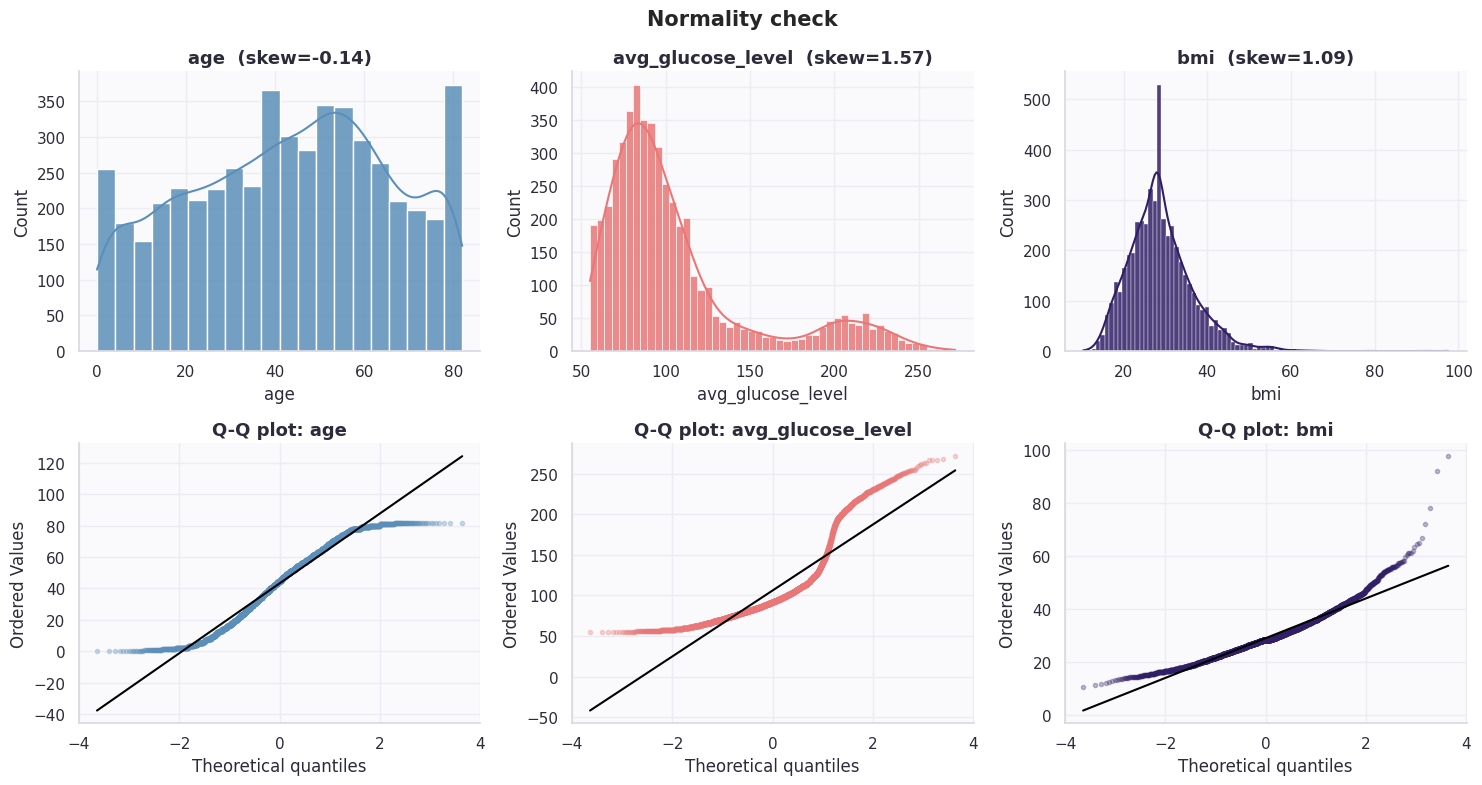

age                D'Agostino p = 6.5e-244
avg_glucose_level  D'Agostino p = 2.2e-289
bmi                D'Agostino p = 2.4e-244


In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for j, (c, col) in enumerate(zip(['age', 'avg_glucose_level', 'bmi'], PALETTE)):
    sns.histplot(df[c], kde=True, ax=ax[0, j], color=col, edgecolor='white', alpha=.85)
    ax[0, j].set_title(f'{c}  (skew={stats.skew(df[c]):.2f})')
    stats.probplot(df[c], dist='norm', plot=ax[1, j])
    ax[1, j].get_lines()[0].set(marker='o', markersize=3, alpha=.3, color=col)
    ax[1, j].get_lines()[1].set(color='black', lw=1.5)
    ax[1, j].set_title(f'Q-Q plot: {c}')
fig.suptitle('Normality check', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

for c in ['age', 'avg_glucose_level', 'bmi']:
    print(f'{c:18s} D\'Agostino p = {stats.normaltest(df[c])[1]:.1e}')

## General Plots

### Distributions by stroke status
Density-normalised KDEs (`common_norm=False`) so the rare stroke group stays visible. Stroke patients are shifted toward older ages and higher glucose.

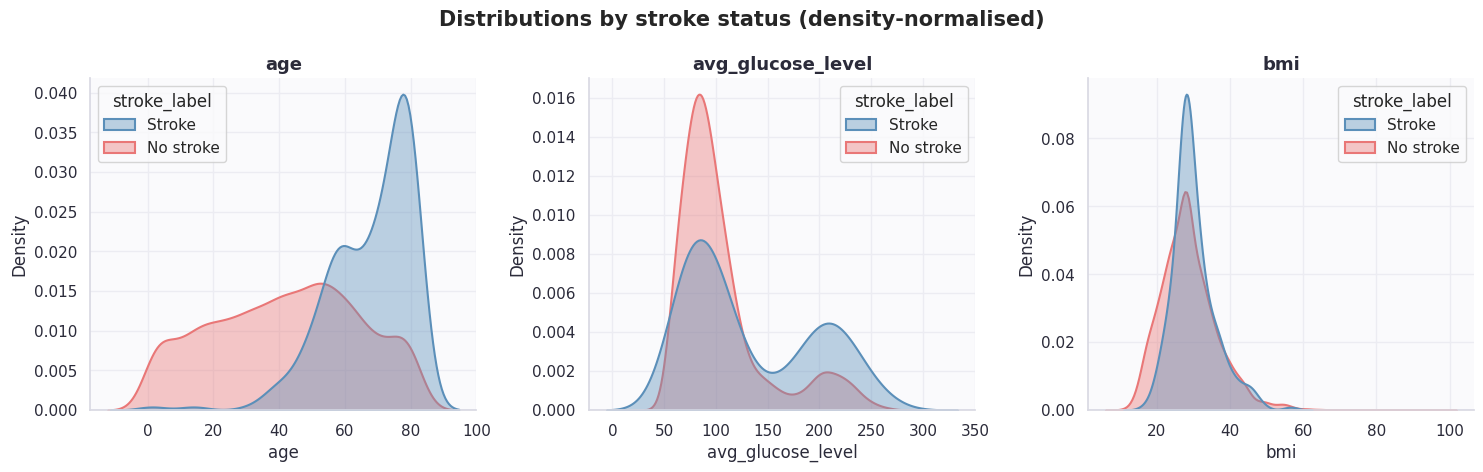

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, col in zip(axes, ['age', 'avg_glucose_level', 'bmi']):
    sns.kdeplot(data=df, x=col, hue='stroke_label', fill=True, alpha=0.4,
                palette=[NO_COLOR, YES_COLOR], ax=ax, common_norm=False, linewidth=1.5)
    ax.set_title(col)
fig.suptitle('Distributions by stroke status (density-normalised)',
             fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

### Correlation heatmap
Spearman (rank-based, since data is non-normal). The upper triangle is masked so each pair appears once. Age shows the strongest correlation with stroke.

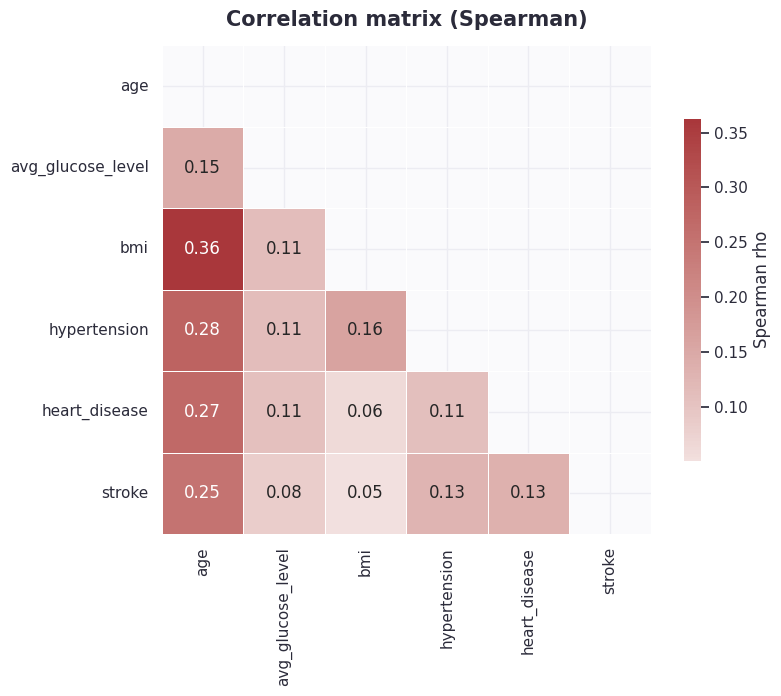

In [ ]:
corr = df[['age', 'avg_glucose_level', 'bmi',
           'hypertension', 'heart_disease', 'stroke']].corr('spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8.5, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='vlag', center=0,
            square=True, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.7, 'label': 'Spearman rho'})
plt.title('Correlation matrix (Spearman)', fontsize=15, pad=14)
plt.tight_layout()
plt.show()

### Scatter plots

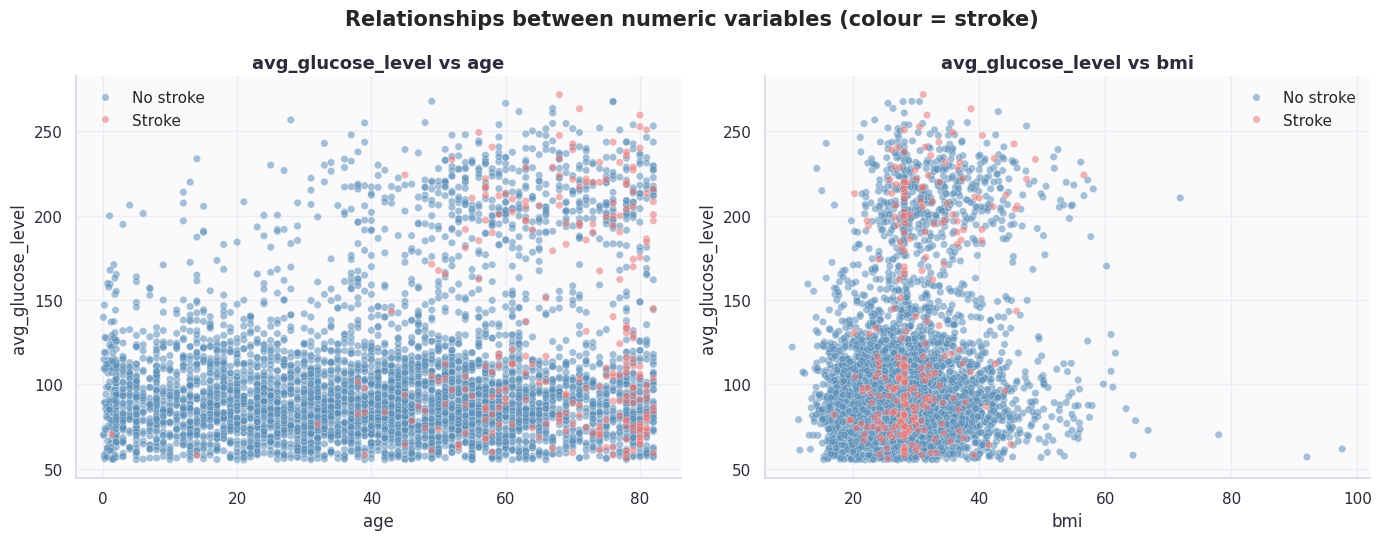

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
order = df.sort_values('stroke')   # non-stroke first, stroke drawn on top
for ax, (xcol, ycol) in zip(axes, [('age', 'avg_glucose_level'),
                                    ('bmi', 'avg_glucose_level')]):
    sns.scatterplot(data=order, x=xcol, y=ycol, hue='stroke_label',
                    palette=[NO_COLOR, YES_COLOR], alpha=0.55, s=28,
                    edgecolor='white', linewidth=0.3, ax=ax)
    ax.set_title(f'{ycol} vs {xcol}'); ax.legend(title='', frameon=False)
fig.suptitle('Relationships between numeric variables (colour = stroke)',
             fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

## Comparisons in graphical representation

### The age effect
Left: age distribution by stroke status. Right: stroke rate climbs steeply with age band.

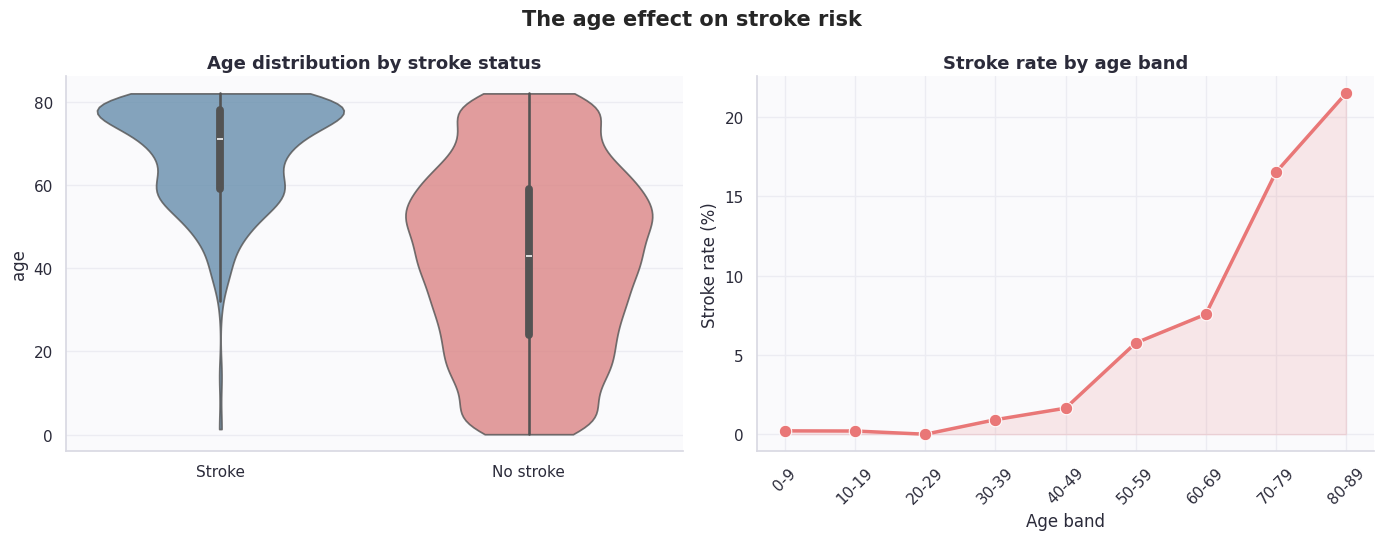

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.violinplot(data=df, x='stroke_label', y='age', hue='stroke_label',
               legend=False, palette=[NO_COLOR, YES_COLOR],
               inner='box', cut=0, ax=axes[0], alpha=0.8)
axes[0].set_title('Age distribution by stroke status'); axes[0].set_xlabel('')
df['age_band'] = pd.cut(df['age'], bins=range(0, 91, 10), right=False,
                        labels=[f'{i}-{i+9}' for i in range(0, 90, 10)])
rate = df.groupby('age_band', observed=True)['stroke'].mean() * 100
sns.lineplot(x=rate.index, y=rate.values, marker='o', markersize=9,
             color=YES_COLOR, linewidth=2.5, ax=axes[1])
axes[1].fill_between(range(len(rate)), rate.values, alpha=0.15, color=YES_COLOR)
axes[1].set_title('Stroke rate by age band')
axes[1].set_xlabel('Age band'); axes[1].set_ylabel('Stroke rate (%)')
axes[1].tick_params(axis='x', rotation=45)
fig.suptitle('The age effect on stroke risk', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

### Stroke rate across risk factors
Because strokes are rare, we plot the *rate* within each category, not raw counts.

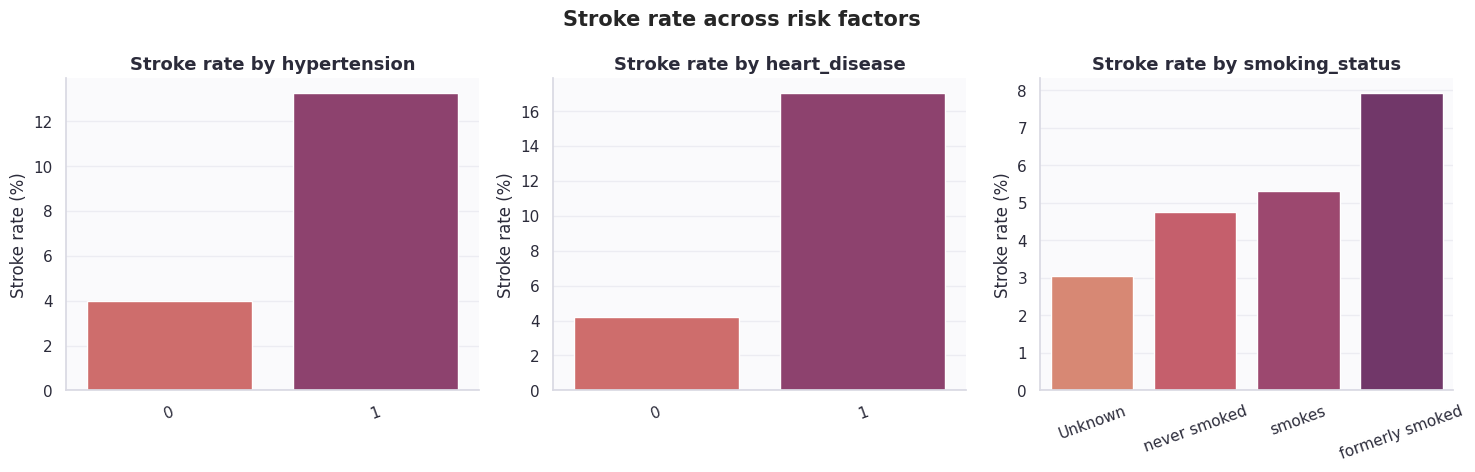

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, col in zip(axes, ['hypertension', 'heart_disease', 'smoking_status']):
    rate = (df.groupby(col, observed=True)['stroke'].mean()*100).sort_values()
    sns.barplot(x=rate.index.astype(str), y=rate.values, hue=rate.index.astype(str),
                legend=False, palette='flare', ax=ax, edgecolor='white')
    ax.set_title(f'Stroke rate by {col}'); ax.set_ylabel('Stroke rate (%)')
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
fig.suptitle('Stroke rate across risk factors', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

### Risk-factor strength and magnitude
Cramer's V (left) measures association strength independent of sample size, odds ratios with 95% CI (right) give direction and magnitude. Heart disease and hypertension lead, gender and residence type are negligible.

hypertension   OR = 3.70  95% CI [2.74, 4.98]
heart_disease  OR = 4.71  95% CI [3.34, 6.64]


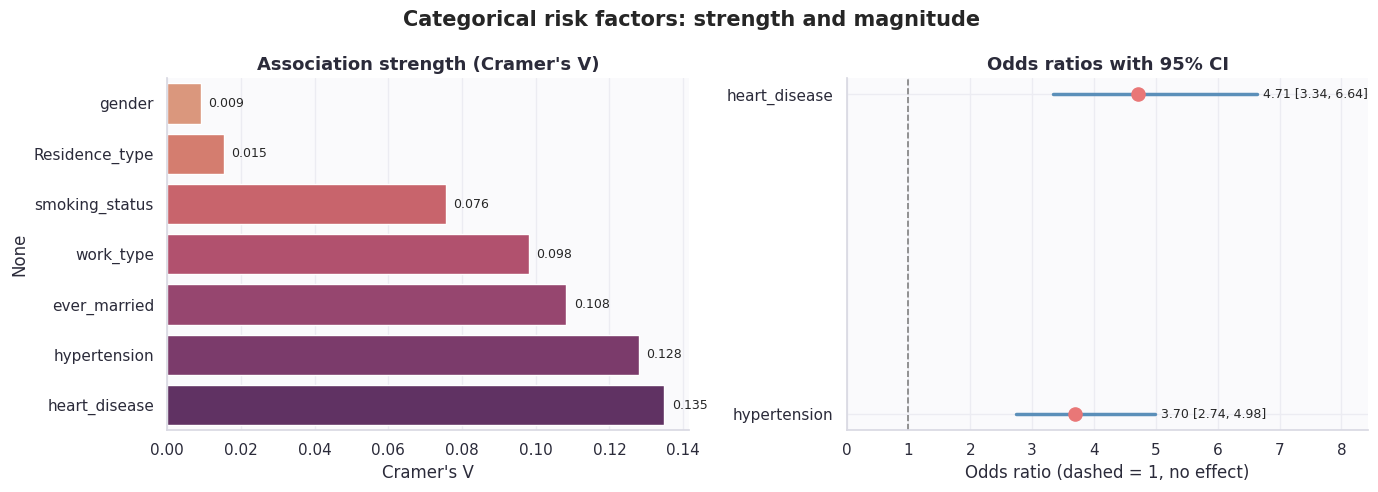

In [ ]:
cat_cols = ['hypertension', 'heart_disease', 'ever_married', 'work_type',
            'Residence_type', 'smoking_status', 'gender']
cramers = {}
for c in cat_cols:
    ct = pd.crosstab(df[c], df['stroke'])
    cramers[c] = association(ct.values, method='cramer')

or_rows = []
for c in ['hypertension', 'heart_disease']:
    t = sm.stats.Table2x2(pd.crosstab(df[c], df['stroke']).values)
    lo, hi = t.oddsratio_confint()
    or_rows.append((c, t.oddsratio, lo, hi))
    print(f'{c:14s} OR = {t.oddsratio:.2f}  95% CI [{lo:.2f}, {hi:.2f}]')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cv = pd.Series(cramers).sort_values()
sns.barplot(x=cv.values, y=cv.index, hue=cv.index, legend=False,
            palette='flare', ax=axes[0], edgecolor='white')
axes[0].set_title('Association strength (Cramer\'s V)'); axes[0].set_xlabel('Cramer\'s V')
for i, val in enumerate(cv.values):
    axes[0].text(val+0.002, i, f'{val:.3f}', va='center', fontsize=9)
for i, (name, orv, lo, hi) in enumerate(or_rows):
    axes[1].plot([lo, hi], [i, i], color=NO_COLOR, lw=2.5, zorder=1)
    axes[1].scatter(orv, i, color=YES_COLOR, s=90, zorder=2)
    axes[1].text(hi+0.1, i, f'{orv:.2f} [{lo:.2f}, {hi:.2f}]', va='center', fontsize=9)
axes[1].axvline(1, color='grey', ls='--', lw=1.2)
axes[1].set_yticks(range(len(or_rows))); axes[1].set_yticklabels([r[0] for r in or_rows])
axes[1].set_xlim(0, max(r[3] for r in or_rows)+1.8)
axes[1].set_title('Odds ratios with 95% CI')
axes[1].set_xlabel('Odds ratio (dashed = 1, no effect)')
fig.suptitle('Categorical risk factors: strength and magnitude',
             fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

## Hypothesis Checking

**H1:** Stroke patients are older than non-stroke patients. <br>
**H2:** *Among hypertensive patients*, stroke patients have higher glucose. <br>
**H3:** The stroke-vs-non-stroke age gap is larger for patients *without* heart disease than those with it. <br>

In [ ]:
# H1
a = df[df.stroke==1]['age']; b = df[df.stroke==0]['age']
U, p = stats.mannwhitneyu(a, b); rbc = 1 - (2*U)/(len(a)*len(b))
print('H1: stroke mean age = %.1f vs %.1f | p = %.2e | rank-biserial = %.2f'
      % (a.mean(), b.mean(), p, rbc))
print('    -> SUPPORTED' if p < 0.05 else '    -> not supported')

H1: stroke mean age = 67.7 vs 42.0 | p = 3.85e-71 | rank-biserial = -0.67
    -> SUPPORTED


In [ ]:
# H2: hypertensive patients only
sub = df[df.hypertension==1]
g1 = sub[sub.stroke==1]['avg_glucose_level']; g0 = sub[sub.stroke==0]['avg_glucose_level']
U2, p2 = stats.mannwhitneyu(g1, g0, alternative='greater')
print('H2: stroke median glucose = %.1f vs %.1f (n_stroke=%d) | p = %.3f'
      % (g1.median(), g0.median(), len(g1), p2))
print('    -> SUPPORTED' if p2 < 0.05 else '    -> NOT supported (suggestive median gap, not significant)')

H2: stroke median glucose = 120.3 vs 103.0 (n_stroke=66) | p = 0.231
    -> NOT supported (suggestive median gap, not significant)


### H3 — the age-gap interaction
The figure below gives understanding: among patients without heart disease the stroke/non-stroke age gap is large, along those with heart disease it nearly disappears.

H3: age gap (stroke - no stroke), split by heart disease
   heart_disease=0: gap = 26.1 yrs | rbc = -0.68 | p = 1.2e-59
   heart_disease=1: gap =  4.4 yrs | rbc = -0.21 | p = 2.4e-02


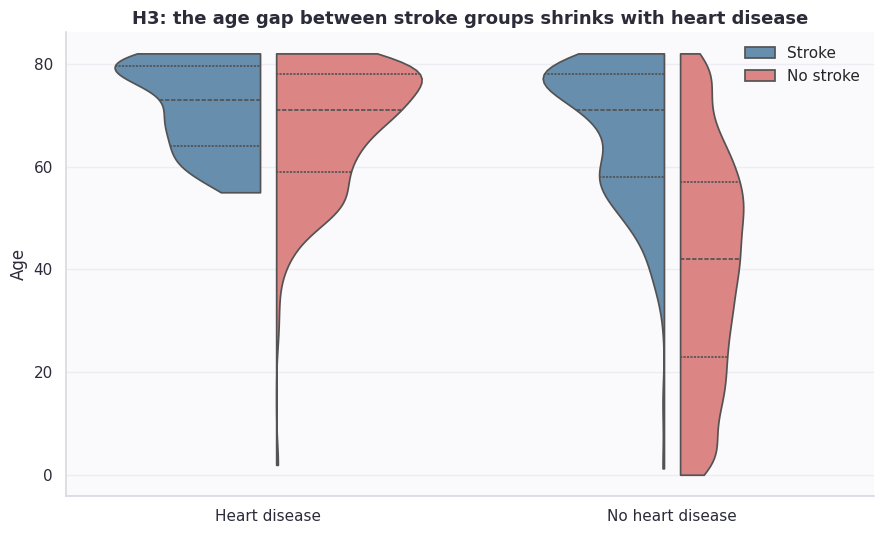

In [ ]:
print('H3: age gap (stroke - no stroke), split by heart disease')
for hd in [0, 1]:
    s = df[df.heart_disease==hd]
    a1 = s[s.stroke==1]['age']; a0 = s[s.stroke==0]['age']
    U, p = stats.mannwhitneyu(a1, a0); rbc = 1 - (2*U)/(len(a1)*len(a0))
    print('   heart_disease=%d: gap = %4.1f yrs | rbc = %.2f | p = %.1e'
          % (hd, a1.mean()-a0.mean(), rbc, p))

df['hd_label'] = df['heart_disease'].map({0: 'No heart disease', 1: 'Heart disease'})
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.violinplot(data=df, x='hd_label', y='age', hue='stroke_label',
               split=True, gap=0.1, inner='quartile',
               palette=[NO_COLOR, YES_COLOR], ax=ax, cut=0)
ax.set_title('H3: the age gap between stroke groups shrinks with heart disease',
             fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Age'); ax.legend(title='', frameon=False)
fig.tight_layout(); plt.show()

## Conclusion

**Age is the strongest single correlate of stroke**, evident in the direct comparison (H1, p ~= 10<sup>-7</sup>) and the rising age-range curve. Chronic conditions - heart disease (4.71) and hypertension (3.70) - are clearly secondary risk factors, while gender and residence type contribute little to none (Cramer's V ≈ 0.01).

The layered hypotheses add nuance. **H2 was not supported**: glucose, although associated with stroke, does not significantly separate stroke outcomes once we remain in the restrictions of hypertensive patients only - a marginal association doesn't need hold within a subgroup. **H3 was supported**: the age gap is ~6x larger for patients without heart disease, which indicates heart disease and age are somewhat redundant risk signals as heart-disease patients are already elderly.

**Limitations:** all Cramer's V values are in the 'weak' band (<0.15), so individual category factors are real though humble. Also `bmi` and the large `Unknown` smoking group introduce blanks, so conclusions involving those fields are softer.